# 05 — Thailand Tambon GIS
## Detailed Polygon Analysis, Cartographic Generalization & Local Choropleth

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Intermediate  
**ข้อมูล:** Thailand ADM1 + ADM2 + ADM3 (Tambon)  
**เครื่องมือ:** GeoPandas · Pandas · Matplotlib · Folium · MapClassify · xyzservices

Notebook นี้ต่อจาก Notebook 04 โดยเพิ่มระดับรายละเอียดของ polygon จาก **อำเภอ (ADM2)** ไปสู่ **ตำบล (ADM3)**

เมื่อจำนวน polygon เพิ่มขึ้น ปัญหาจะไม่ได้มีแค่ “คำนวณได้หรือไม่” แต่จะรวมถึง

- map clutter
- label collision
- visual hierarchy
- performance
- choice of extent
- classification
- cartographic generalization

แกนหลัก:

$$
\text{ADM3}
\rightarrow
\text{Inspect}
\rightarrow
\text{Hierarchy}
\rightarrow
\text{Measure}
\rightarrow
\text{Rank}
\rightarrow
\text{Summarize}
\rightarrow
\text{Filter}
\rightarrow
\text{Map}
\rightarrow
\text{Communicate}
$$

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบายตำแหน่งของ ADM3 ใน administrative hierarchy
2. ตรวจ schema, CRS, geometry และ identifier ของข้อมูลตำบล
3. อธิบายแนวคิด simplified geometry และข้อจำกัด
4. คำนวณพื้นที่ตำบลทั่วประเทศด้วย equal-area projection
5. หา Top 50 ตำบลที่มีพื้นที่มากที่สุด
6. สรุปจำนวนตำบลต่อจังหวัดและต่ออำเภอ
7. Query ตำบลในจังหวัดพิษณุโลก
8. คำนวณพื้นที่ตำบลพิษณุโลกด้วย EPSG:32647
9. สร้าง reference map และ choropleth ที่ระดับตำบล
10. จัดการ label clutter ตาม map extent
11. ตรวจ ADM3 → ADM2 hierarchy ด้วย spatial join แบบย่อ
12. ใช้ Folium พร้อม basemap switcher และ Esri World Imagery
13. Export PNG 300 dpi, GeoPackage, Shapefile, CSV และ HTML

## Recap จาก Notebook 04

Notebook 04 เพิ่มแนวคิด

$$
\boxed{
\text{Hierarchy}
+
\text{Spatial relationship}
+
\text{Spatial Join}
+
\text{Validation}
}
$$

Notebook 05 เพิ่มคำถามใหม่:

> เมื่อ polygon มีจำนวนมากและละเอียดขึ้น เราจะวิเคราะห์และสื่อสารผลอย่างไรโดยไม่ทำให้แผนที่อ่านยาก?

หลักสำคัญ:

$$
\boxed{
More\ spatial\ detail
\rightarrow
greater\ need\ for\ cartographic\ selection
}
$$

## คำถามเปิดบท

ถ้าเราใส่ชื่อทุกตำบลทั่วประเทศลงบนแผนที่เดียว จะเกิดอะไรขึ้น?

คำตอบมักไม่ใช่ “แผนที่ละเอียดขึ้น” แต่เป็น

```text
too many labels
↓
overlap
↓
visual clutter
↓
lower readability
```

ดังนั้น

> **More features ≠ more useful labels**

## 1. ติดตั้ง libraries

In [1]:
%pip -q install geopandas folium mapclassify xyzservices pyogrio

In [2]:
import json
from pathlib import Path
import shutil
import zipfile

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import folium
import xyzservices.providers as xyz
import mapclassify

from IPython.display import display

print("GeoPandas  :", gpd.__version__)
print("Pandas     :", pd.__version__)
print("Folium     :", folium.__version__)
print("MapClassify:", mapclassify.__version__)

GeoPandas  : 1.2.0
Pandas     : 2.2.3
Folium     : 0.20.0
MapClassify: 2.10.0


## 2. Font ภาษาไทย — Sarabun

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 3. Workspace

In [4]:
DATA_DIR = Path("/content/gis05_data")
OUTPUT_DIR = Path("/content/gis05_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder   :", DATA_DIR)
print("Output folder :", OUTPUT_DIR)

Data folder   : /content/gis05_data
Output folder : /content/gis05_outputs


## 4. Download helper

In [5]:
def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        zip_path.write_bytes(response.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(
            f"ไม่พบ .shp ใน {zip_name}"
        )

    print("ZIP      :", zip_path)
    print("Extracted:", extract_dir)
    print("Shapefile:", shp_files[0])

    return shp_files[0]

## 5. Helper สำหรับค้นหา field

In [6]:
def find_column(gdf, candidates, required=False):
    lookup = {
        str(c).upper(): c
        for c in gdf.columns
    }

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field ที่คาดไว้: "
            + ", ".join(candidates)
            + "\nFields จริง: "
            + ", ".join(map(str, gdf.columns))
        )

    return None

# Part A — Load ADM1 + ADM2 + ADM3

## 6. Download ADM1 — จังหวัด

In [7]:
ADM1_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm1/tha_adm1_province_shapefile.zip"
)

adm1_shp = download_and_extract_zip(
    ADM1_URL,
    "tha_adm1_province_shapefile.zip",
    "tha_adm1"
)

ZIP      : /content/gis05_data/tha_adm1_province_shapefile.zip
Extracted: /content/gis05_data/tha_adm1
Shapefile: /content/gis05_data/tha_adm1/tha_adm1_province.shp


## 7. Download ADM2 — อำเภอ

In [8]:
ADM2_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm2/tha_admbnda_adm2_shapefile.zip"
)

adm2_shp = download_and_extract_zip(
    ADM2_URL,
    "tha_admbnda_adm2_shapefile.zip",
    "tha_adm2"
)

ZIP      : /content/gis05_data/tha_admbnda_adm2_shapefile.zip
Extracted: /content/gis05_data/tha_adm2
Shapefile: /content/gis05_data/tha_adm2/tha_admbnda_adm2.shp


## 8. Download ADM3 — ตำบล

In [9]:
ADM3_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tambon_simplify/tha_admbnda_adm3_rtsd_20220121.zip"
)

adm3_shp = download_and_extract_zip(
    ADM3_URL,
    "tha_admbnda_adm3_rtsd_20220121.zip",
    "tha_adm3"
)

ZIP      : /content/gis05_data/tha_admbnda_adm3_rtsd_20220121.zip
Extracted: /content/gis05_data/tha_adm3
Shapefile: /content/gis05_data/tha_adm3/tha_admbnda_adm3_rtsd_20220121.shp


## 9. Read all layers with UTF-8

In [10]:
province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)

district = gpd.read_file(
    adm2_shp,
    encoding="UTF-8"
)

tambon = gpd.read_file(
    adm3_shp,
    encoding="UTF-8"
)

print("Province features:", len(province))
print("District features:", len(district))
print("Tambon features  :", len(tambon))

print("\nCRS")
print("ADM1:", province.crs)
print("ADM2:", district.crs)
print("ADM3:", tambon.crs)

Province features: 77
District features: 928
Tambon features  : 7425

CRS
ADM1: EPSG:4326
ADM2: EPSG:4326
ADM3: EPSG:4326


## 10. Inspect ADM3 schema

In [11]:
print(list(tambon.columns))
display(tambon.head())

['Shape_Leng', 'Shape_Area', 'ADM3_EN', 'ADM3_TH', 'ADM3_PCODE', 'ADM3_REF', 'ADM3ALT1EN', 'ADM3ALT2EN', 'ADM3ALT1TH', 'ADM3ALT2TH', 'ADM2_EN', 'ADM2_TH', 'ADM2_PCODE', 'ADM1_EN', 'ADM1_TH', 'ADM1_PCODE', 'ADM0_EN', 'ADM0_TH', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry']


,Shape_Leng,Shape_Area,ADM3_EN,ADM3_TH,ADM3_PCODE,ADM3_REF,ADM3ALT1EN,ADM3ALT2EN,ADM3ALT1TH,ADM3ALT2TH,...,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,0.047699,0.000128,Phraborom Maharatchawang,พระบรมมหาราชวัง,TH100101,None,None,None,None,None,...,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18,2022-01-22,NaT,"POLYGON ((100.49453 13.75759, 100.49494 13.757..."
1,0.033550,0.000061,Wang Burapha Phirom,วังบูรพาภิรมย์,TH100102,None,None,None,None,None,...,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18,2022-01-22,NaT,"POLYGON ((100.50131 13.748, 100.50412 13.74771..."
2,0.017289,0.000018,Wat Ratchabophit,วัดราชบพิธ,TH100103,None,None,None,None,None,...,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18,2022-01-22,NaT,"POLYGON ((100.50131 13.748, 100.49633 13.74849..."
3,0.019046,0.000019,Samran Rat,สำราญราษฎร์,TH100104,None,None,None,None,None,...,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18,2022-01-22,NaT,"POLYGON ((100.50554 13.75378, 100.50412 13.747..."
4,0.015232,0.000013,San Chaopho Suea,ศาลเจ้าพ่อเสือ,TH100105,None,None,None,None,None,...,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18,2022-01-22,NaT,"POLYGON ((100.49875 13.7556, 100.49821 13.7514..."


## 11. หา field สำคัญจาก schema จริง

In [12]:
p_adm1_code = find_column(
    province,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

p_adm1_th = find_column(
    province,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

d_adm1_code = find_column(
    district,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

d_adm2_code = find_column(
    district,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

d_adm2_th = find_column(
    district,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

t_adm1_code = find_column(
    tambon,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

t_adm1_th = find_column(
    tambon,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

t_adm2_code = find_column(
    tambon,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

t_adm2_th = find_column(
    tambon,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

t_adm3_code = find_column(
    tambon,
    ["ADM3_PCODE", "ADM3_CODE"],
    required=True
)

t_adm3_th = find_column(
    tambon,
    ["ADM3_TH", "NAME_3_TH"],
    required=True
)

t_adm3_en = find_column(
    tambon,
    ["ADM3_EN", "NAME_3"],
    required=False
)

print("Tambon province field :", t_adm1_th)
print("Tambon district field :", t_adm2_th)
print("Tambon name field     :", t_adm3_th)
print("Tambon code field     :", t_adm3_code)

Tambon province field : ADM1_TH
Tambon district field : ADM2_TH
Tambon name field     : ADM3_TH
Tambon code field     : ADM3_PCODE


## 12. ตรวจภาษาไทยและ hierarchy

In [13]:
cols_show = [
    t_adm1_th,
    t_adm2_th,
    t_adm3_th,
    t_adm3_code
]

if t_adm3_en:
    cols_show.insert(3, t_adm3_en)

display(
    tambon[
        cols_show
    ].head(15)
)

,ADM1_TH,ADM2_TH,ADM3_TH,ADM3_EN,ADM3_PCODE
0,กรุงเทพมหานคร,พระนคร,พระบรมมหาราชวัง,Phraborom Maharatchawang,TH100101
1,กรุงเทพมหานคร,พระนคร,วังบูรพาภิรมย์,Wang Burapha Phirom,TH100102
2,กรุงเทพมหานคร,พระนคร,วัดราชบพิธ,Wat Ratchabophit,TH100103
3,กรุงเทพมหานคร,พระนคร,สำราญราษฎร์,Samran Rat,TH100104
4,กรุงเทพมหานคร,พระนคร,ศาลเจ้าพ่อเสือ,San Chaopho Suea,TH100105
5,กรุงเทพมหานคร,พระนคร,เสาชิงช้า,Sao Chingcha,TH100106
6,กรุงเทพมหานคร,พระนคร,บวรนิเวศ,Bowon Niwet,TH100107
7,กรุงเทพมหานคร,พระนคร,ตลาดยอด,Talat Yot,TH100108
8,กรุงเทพมหานคร,พระนคร,ชนะสงคราม,Chana Songkhram,TH100109
9,กรุงเทพมหานคร,พระนคร,บ้านพานถม,Ban Phan Thom,TH100110


## 13. Geometry Quality Control

In [14]:
qc = pd.DataFrame({
    "Province": [
        len(province),
        province.geometry.isna().sum(),
        province.geometry.is_empty.sum(),
        (~province.is_valid.fillna(False)).sum()
    ],
    "District": [
        len(district),
        district.geometry.isna().sum(),
        district.geometry.is_empty.sum(),
        (~district.is_valid.fillna(False)).sum()
    ],
    "Tambon": [
        len(tambon),
        tambon.geometry.isna().sum(),
        tambon.geometry.is_empty.sum(),
        (~tambon.is_valid.fillna(False)).sum()
    ]
}, index=[
    "All features",
    "Missing geometry",
    "Empty geometry",
    "Invalid / unavailable"
])

display(qc)

print("\nTambon geometry types:")
display(tambon.geom_type.value_counts())

,Province,District,Tambon
All features,77,928,7425
Missing geometry,0,0,0
Empty geometry,0,0,0
Invalid / unavailable,0,1,0



Tambon geometry types:


,count
Polygon,7387
MultiPolygon,38


# Part B — ADM3 Hierarchy & Simplified Geometry

## 14. Administrative hierarchy

$$
ADM3 \subset ADM2 \subset ADM1
$$

เชิงแนวคิด:

```text
Province
  ↓
District
  ↓
Tambon
```

หนึ่ง record ของตำบลมีทั้ง parent district และ parent province อยู่ใน attribute table

## 15. Unique ADM3 identifier

ตรวจว่ารหัสตำบลสามารถใช้เป็น feature identifier ได้หรือไม่

In [15]:
id_summary = pd.DataFrame({
    "Metric": [
        "Tambon features",
        "Unique ADM3 codes",
        "Duplicated ADM3 codes",
        "Unique ADM2 parents",
        "Unique ADM1 parents"
    ],
    "Value": [
        len(tambon),
        tambon[t_adm3_code].nunique(),
        tambon[t_adm3_code].duplicated().sum(),
        tambon[t_adm2_code].nunique(),
        tambon[t_adm1_code].nunique()
    ]
})

display(id_summary)

,Metric,Value
0,Tambon features,7425
1,Unique ADM3 codes,7425
2,Duplicated ADM3 codes,0
3,Unique ADM2 parents,928
4,Unique ADM1 parents,77


## 16. Simplified geometry คืออะไร?

Dataset นี้อยู่ใน folder `tambon_simplify`

แนวคิด:

```text
Original boundary
many vertices
      ↓
Simplification
      ↓
fewer vertices
      ↓
smaller file
faster display
```

ข้อดี:

- แสดงผลเร็วขึ้น
- file size เล็กลง
- เหมาะกับ teaching / web map / regional analysis

ข้อควรระวัง:

$$
\boxed{
Simplified\ boundary
\neq
survey\ or\ cadastral\ boundary
}
$$

จึงไม่ควรใช้แทนขอบเขตกฎหมายหรือการรังวัดที่ต้องการความแม่นยำสูง

# Part C — National Tambon View

## 17. แผนที่ขอบเขตตำบลทั้งประเทศ

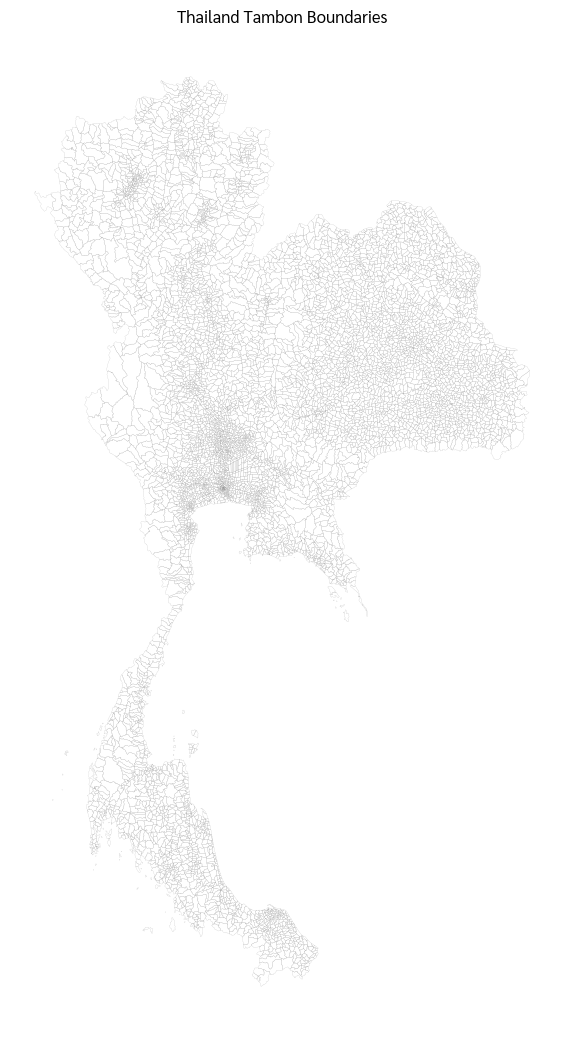

In [16]:
fig, ax = plt.subplots(figsize=(9, 13))

tambon.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.08
)

ax.set_title(
    "Thailand Tambon Boundaries"
)
ax.set_axis_off()

plt.show()

## 18. Map detail must match map scale

เมื่อจำนวน polygon เพิ่มขึ้น:

$$
More\ features
\rightarrow
more\ visual\ complexity
$$

ดังนั้น strategy ควรเปลี่ยนตาม extent

```text
Thailand
→ no tambon labels

Province
→ labels may be possible

District
→ detailed labels are usually appropriate
```

หลัก:

$$
\boxed{
Level\ of\ detail
must\ match
map\ scale
}
$$

## 19. ทำไมไม่ label ทุกตำบลทั่วประเทศ?

ถ้าใส่ชื่อทุกตำบล:

```text
thousands of labels
↓
overlap
↓
unreadable map
```

ดังนั้น

> **Filter before you visualize**

# Part D — Tambon Area

## 20. Reproject เป็น Equal-area CRS

เพื่อเปรียบเทียบพื้นที่ตำบลทั่วประเทศ ใช้ EPSG:6933

$$
A_{km^2}
=
\frac{A_{m^2}}{10^6}
$$

In [17]:
tambon_ea = tambon.to_crs(
    "EPSG:6933"
)

tambon_ea["area_km2"] = (
    tambon_ea.geometry.area
    / 1_000_000
)

print("Analysis CRS:", tambon_ea.crs)

display(
    tambon_ea[
        [
            t_adm1_th,
            t_adm2_th,
            t_adm3_th,
            "area_km2"
        ]
    ].head(10)
)

Analysis CRS: EPSG:6933


,ADM1_TH,ADM2_TH,ADM3_TH,area_km2
0,กรุงเทพมหานคร,พระนคร,พระบรมมหาราชวัง,1.338205
1,กรุงเทพมหานคร,พระนคร,วังบูรพาภิรมย์,0.805858
2,กรุงเทพมหานคร,พระนคร,วัดราชบพิธ,0.208782
3,กรุงเทพมหานคร,พระนคร,สำราญราษฎร์,0.235054
4,กรุงเทพมหานคร,พระนคร,ศาลเจ้าพ่อเสือ,0.154144
5,กรุงเทพมหานคร,พระนคร,เสาชิงช้า,0.155260
6,กรุงเทพมหานคร,พระนคร,บวรนิเวศ,0.511787
7,กรุงเทพมหานคร,พระนคร,ตลาดยอด,0.095387
8,กรุงเทพมหานคร,พระนคร,ชนะสงคราม,0.362088
9,กรุงเทพมหานคร,พระนคร,บ้านพานถม,0.495199


## 21. Descriptive statistics

In [18]:
tambon_area_desc = (
    tambon_ea["area_km2"]
    .describe()
    .to_frame("area_km2")
)

display(
    tambon_area_desc.round(2)
)

,area_km2
count,7425.00
mean,69.39
std,97.68
min,0.10
25%,23.97
50%,45.38
75%,79.42
max,2077.95


## 22. Histogram ของพื้นที่ตำบล

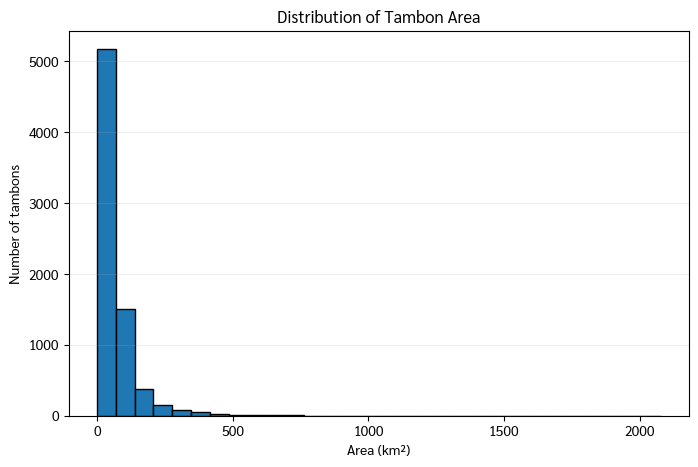

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    tambon_ea["area_km2"],
    bins=30,
    edgecolor="black"
)

ax.set_title("Distribution of Tambon Area")
ax.set_xlabel("Area (km²)")
ax.set_ylabel("Number of tambons")
ax.grid(axis="y", alpha=0.2)

plt.show()

# Part E — Top 50 Largest Tambons

## 23. Ranking

In [21]:
top50 = (
    tambon_ea
    .nlargest(
        50,
        "area_km2"
    )
    .copy()
)

top50["rank"] = range(
    1,
    len(top50) + 1
)

display(
    top50[
        [
            "rank",
            t_adm1_th,
            t_adm2_th,
            t_adm3_th,
            "area_km2"
        ]
    ].round(1)
)

,rank,ADM1_TH,ADM2_TH,ADM3_TH,area_km2
5283,1,ตาก,สามเงา,บ้านนา,2078.0
5316,2,ตาก,อุ้มผาง,แม่ละมุ้ง,2046.3
5164,3,อุทัยธานี,บ้านไร่,แก่นมะกรูด,1849.7
5876,4,กาญจนบุรี,ทองผาภูมิ,ชะแล,1680.5
5881,5,กาญจนบุรี,สังขละบุรี,ไล่โว่,1548.1
6292,6,เพชรบุรี,แก่งกระจาน,ห้วยแม่เพรียง,1458.8
5315,7,ตาก,อุ้มผาง,แม่จัน,1430.2
6693,8,สุราษฎร์ธานี,บ้านตาขุน,เขาพัง,1368.0
5879,9,กาญจนบุรี,สังขละบุรี,หนองลู,1096.3
4957,10,แม่ฮ่องสอน,แม่สะเรียง,แม่คง,1046.6


## 24. Graph Top 20

เราคำนวณ Top 50 แต่แสดงกราฟ Top 20 เพื่อ readability

> จำนวนข้อมูลที่วิเคราะห์ได้ ไม่จำเป็นต้องเท่ากับจำนวนที่ควรแสดงใน figure

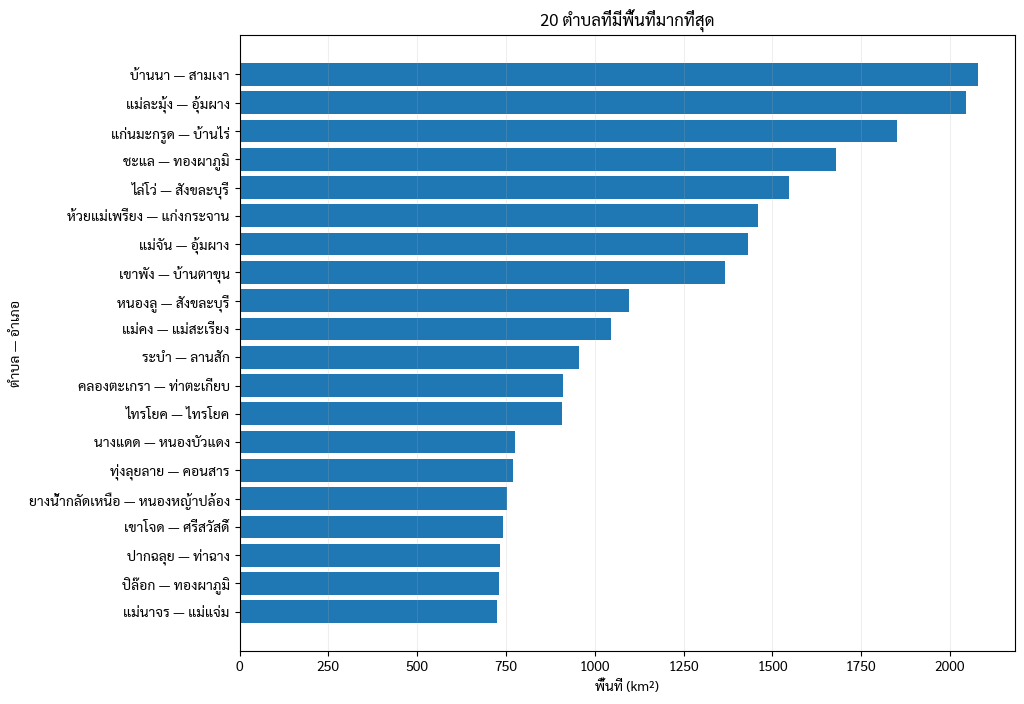

In [22]:
top20 = top50.head(20).copy()

top20_plot = top20.sort_values(
    "area_km2",
    ascending=True
)

labels_top20 = (
    top20_plot[t_adm3_th].astype(str)
    + " — "
    + top20_plot[t_adm2_th].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    labels_top20,
    top20_plot["area_km2"]
)

ax.set_title(
    "20 ตำบลที่มีพื้นที่มากที่สุด"
)
ax.set_xlabel("พื้นที่ (km²)")
ax.set_ylabel("ตำบล — อำเภอ")
ax.grid(axis="x", alpha=0.2)

plt.show()

## 25. Map Top 50 — label เฉพาะ Top 10

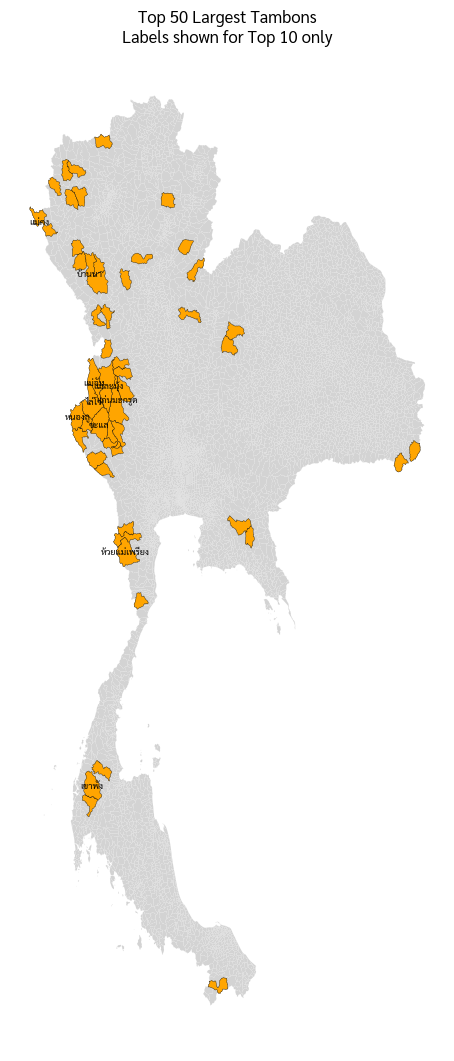

In [23]:
top50_codes = set(
    top50[t_adm3_code]
)

top50_map = tambon_ea[
    tambon_ea[t_adm3_code]
    .isin(top50_codes)
].copy()

top10_map = top50.head(10).copy()

fig, ax = plt.subplots(figsize=(9, 13))

tambon_ea.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.04
)

top50_map.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=0.25
)

top10_pts = (
    top10_map.geometry
    .representative_point()
)

for idx, pt in top10_pts.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            top10_map.loc[
                idx,
                t_adm3_th
            ]
        ),
        fontsize=6.5,
        ha="center",
        va="center"
    )

ax.set_title(
    "Top 50 Largest Tambons\n"
    "Labels shown for Top 10 only"
)

ax.set_axis_off()

plt.show()

หลักสำคัญ:

$$
\boxed{
Analytical\ completeness
\neq
cartographic\ completeness
}
$$

เราเก็บ Top 50 ครบใน table แต่ไม่จำเป็นต้อง label ทั้ง 50 บน figure

# Part F — Tambon Counts by Province and District

## 26. จำนวนตำบลต่อจังหวัด

In [24]:
tambon_count_province = (
    tambon
    .groupby(
        [
            t_adm1_code,
            t_adm1_th
        ],
        as_index=False
    )
    .agg(
        tambon_count=(
            t_adm3_code,
            "count"
        )
    )
    .sort_values(
        "tambon_count",
        ascending=False
    )
)

display(
    tambon_count_province.head(15)
)

,ADM1_PCODE,ADM1_TH,tambon_count
18,TH30,นครราชสีมา,289
22,TH34,อุบลราชธานี,219
4,TH14,พระนครศรีอยุธยา,209
21,TH33,ศรีสะเกษ,206
38,TH50,เชียงใหม่,204
28,TH40,ขอนแก่น,199
33,TH45,ร้อยเอ็ด,193
19,TH31,บุรีรัมย์,189
63,TH80,นครศรีธรรมราช,170
0,TH10,กรุงเทพมหานคร,169


## 27. Top 10 จังหวัดที่มีตำบลมากที่สุด

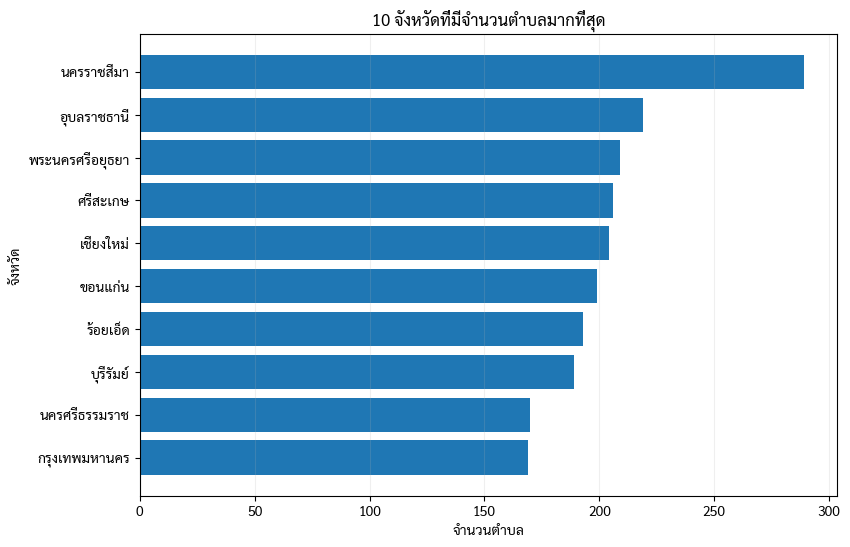

In [25]:
top10_tambon_province = (
    tambon_count_province
    .head(10)
    .sort_values(
        "tambon_count",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top10_tambon_province[t_adm1_th],
    top10_tambon_province["tambon_count"]
)

ax.set_title(
    "10 จังหวัดที่มีจำนวนตำบลมากที่สุด"
)
ax.set_xlabel("จำนวนตำบล")
ax.set_ylabel("จังหวัด")
ax.grid(axis="x", alpha=0.2)

plt.show()

จำนวนตำบลมาก ไม่ได้หมายความว่าจังหวัดมีพื้นที่มากเสมอไป

$$
Count
eq Area
$$

## 28. จำนวนตำบลต่ออำเภอ

In [26]:
tambon_count_district = (
    tambon
    .groupby(
        [
            t_adm1_th,
            t_adm2_code,
            t_adm2_th
        ],
        as_index=False
    )
    .agg(
        tambon_count=(
            t_adm3_code,
            "count"
        )
    )
    .sort_values(
        "tambon_count",
        ascending=False
    )
)

display(
    tambon_count_district.head(15)
)

,ADM1_TH,ADM2_PCODE,ADM2_TH,tambon_count
239,นครราชสีมา,TH3001,เมืองนครราชสีมา,25
220,นครปฐม,TH7301,เมืองนครปฐม,25
556,ลพบุรี,TH1601,เมืองลพบุรี,24
222,นครปฐม,TH7303,นครชัยศรี,24
880,เพชรบุรี,TH7601,เมืองเพชรบุรี,24
890,เพชรบูรณ์,TH6703,หล่มสัก,23
411,พระนครศรีอยุธยา,TH1404,บางไทร,23
814,อุบลราชธานี,TH3411,ตระการพืชผล,23
526,ราชบุรี,TH7001,เมืองราชบุรี,22
561,ลพบุรี,TH1606,บ้านหมี่,22


## 29. Top 10 อำเภอที่มีตำบลมากที่สุด

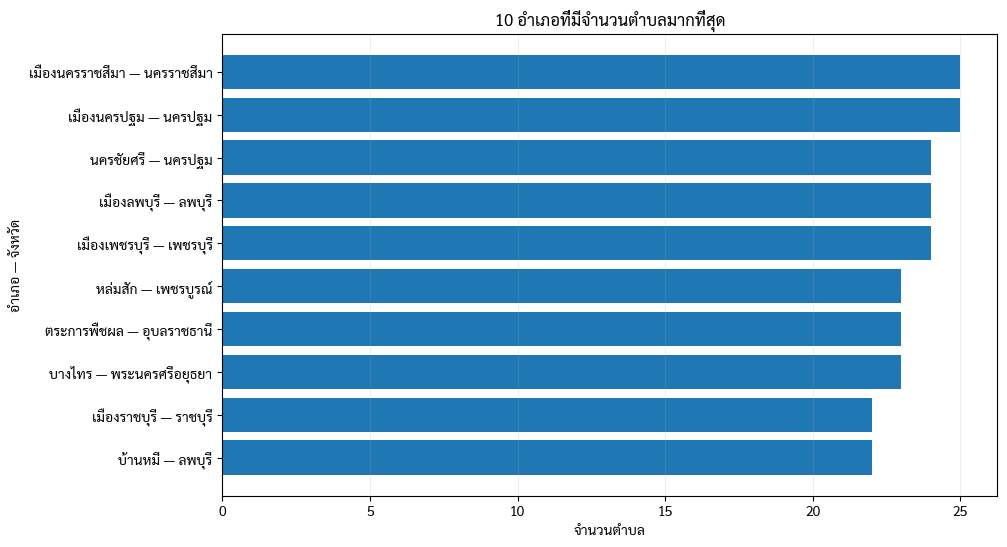

In [27]:
top10_tambon_district = (
    tambon_count_district
    .head(10)
    .sort_values(
        "tambon_count",
        ascending=True
    )
)

district_labels = (
    top10_tambon_district[t_adm2_th].astype(str)
    + " — "
    + top10_tambon_district[t_adm1_th].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    district_labels,
    top10_tambon_district["tambon_count"]
)

ax.set_title(
    "10 อำเภอที่มีจำนวนตำบลมากที่สุด"
)
ax.set_xlabel("จำนวนตำบล")
ax.set_ylabel("อำเภอ — จังหวัด")
ax.grid(axis="x", alpha=0.2)

plt.show()

# Part G — Focus: จังหวัดพิษณุโลก

## 30. Query ตำบลในจังหวัดพิษณุโลก

In [28]:
phs_tambon = tambon[
    tambon[t_adm1_th]
    .astype(str)
    .str.contains(
        "พิษณุโลก",
        na=False
    )
].copy()

print(
    "Tambons in Phitsanulok:",
    len(phs_tambon)
)

print(
    "Districts represented:",
    phs_tambon[
        t_adm2_code
    ].nunique()
)

display(
    phs_tambon[
        [
            t_adm2_th,
            t_adm3_th,
            t_adm3_code
        ]
    ].sort_values(
        [
            t_adm2_th,
            t_adm3_th
        ]
    )
)

Tambons in Phitsanulok: 93
Districts represented: 9


,ADM2_TH,ADM3_TH,ADM3_PCODE
5439,ชาติตระการ,ชาติตระการ,TH650302
5443,ชาติตระการ,ท่าสะแก,TH650306
5442,ชาติตระการ,บ่อภาค,TH650305
5441,ชาติตระการ,บ้านดง,TH650304
5438,ชาติตระการ,ป่าแดง,TH650301
...,...,...,...
5413,เมืองพิษณุโลก,สมอแข,TH650107
5417,เมืองพิษณุโลก,หัวรอ,TH650111
5423,เมืองพิษณุโลก,อรัญญิก,TH650117
5407,เมืองพิษณุโลก,ในเมือง,TH650101


## 31. จำนวนตำบลต่ออำเภอในพิษณุโลก

In [29]:
phs_count_by_district = (
    phs_tambon
    .groupby(
        [
            t_adm2_code,
            t_adm2_th
        ],
        as_index=False
    )
    .agg(
        tambon_count=(
            t_adm3_code,
            "count"
        )
    )
    .sort_values(
        "tambon_count",
        ascending=False
    )
)

display(phs_count_by_district)

,ADM2_PCODE,ADM2_TH,tambon_count
0,TH6501,เมืองพิษณุโลก,20
5,TH6506,พรหมพิราม,12
1,TH6502,นครไทย,11
7,TH6508,วังทอง,11
3,TH6504,บางระกำ,11
4,TH6505,บางกระทุ่ม,9
8,TH6509,เนินมะปราง,7
2,TH6503,ชาติตระการ,6
6,TH6507,วัดโบสถ์,6


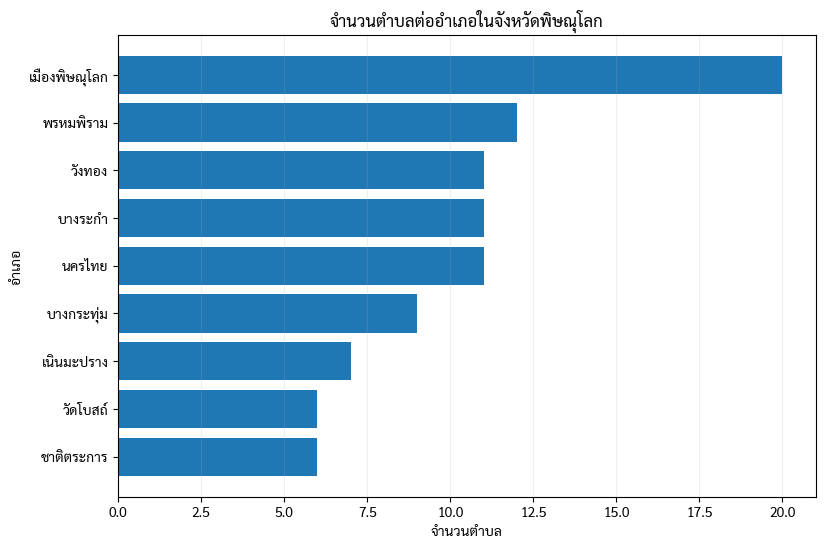

In [30]:
phs_count_plot = (
    phs_count_by_district
    .sort_values(
        "tambon_count",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    phs_count_plot[t_adm2_th],
    phs_count_plot["tambon_count"]
)

ax.set_title(
    "จำนวนตำบลต่ออำเภอในจังหวัดพิษณุโลก"
)
ax.set_xlabel("จำนวนตำบล")
ax.set_ylabel("อำเภอ")
ax.grid(axis="x", alpha=0.2)

plt.show()

## 32. Query ADM1 และ ADM2 ของพิษณุโลก

In [31]:
phs_province = province[
    province[p_adm1_th]
    .astype(str)
    .str.contains(
        "พิษณุโลก",
        na=False
    )
].copy()

phs_district = district[
    district[d_adm1_code]
    .astype(str)
    .isin(
        phs_tambon[
            t_adm1_code
        ].astype(str).unique()
    )
].copy()

print("Province features:", len(phs_province))
print("District features:", len(phs_district))

Province features: 1
District features: 9


## 33. Reproject พิษณุโลกเป็น EPSG:32647

In [32]:
phs_tambon_utm = phs_tambon.to_crs(
    "EPSG:32647"
)

phs_district_utm = phs_district.to_crs(
    "EPSG:32647"
)

phs_province_utm = phs_province.to_crs(
    "EPSG:32647"
)

phs_tambon_utm["area_km2"] = (
    phs_tambon_utm.geometry.area
    / 1_000_000
)

print("CRS:", phs_tambon_utm.crs)

CRS: EPSG:32647


## 34. Summary พื้นที่ตำบลพิษณุโลก

In [33]:
phs_area_summary = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Area_km2": [
        len(phs_tambon_utm),
        phs_tambon_utm["area_km2"].mean(),
        phs_tambon_utm["area_km2"].median(),
        phs_tambon_utm["area_km2"].min(),
        phs_tambon_utm["area_km2"].max()
    ]
})

display(
    phs_area_summary.round(2)
)

,Statistic,Area_km2
0,Count,93.00
1,Mean,113.16
2,Median,70.31
3,Minimum,8.25
4,Maximum,666.86


## 35. Top 10 ตำบลใหญ่ที่สุดในพิษณุโลก

In [34]:
phs_top10 = (
    phs_tambon_utm
    .nlargest(
        10,
        "area_km2"
    )
    .copy()
)

phs_top10["rank"] = range(
    1,
    len(phs_top10) + 1
)

display(
    phs_top10[
        [
            "rank",
            t_adm2_th,
            t_adm3_th,
            "area_km2"
        ]
    ].round(1)
)

,rank,ADM2_TH,ADM3_TH,area_km2
5489,1,วังทอง,วังนกแอ่น,666.9
5442,2,ชาติตระการ,บ่อภาค,652.0
5493,3,เนินมะปราง,ชมพู,486.5
5428,4,นครไทย,หนองกะท้าว,465.7
5481,5,วัดโบสถ์,คันโช้ง,406.8
5441,6,ชาติตระการ,บ้านดง,348.3
5485,7,วังทอง,บ้านกลาง,325.9
5430,8,นครไทย,เนินเพิ่ม,317.4
5435,9,นครไทย,บ่อโพธิ์,304.7
5437,10,นครไทย,ห้วยเฮี้ย,276.7


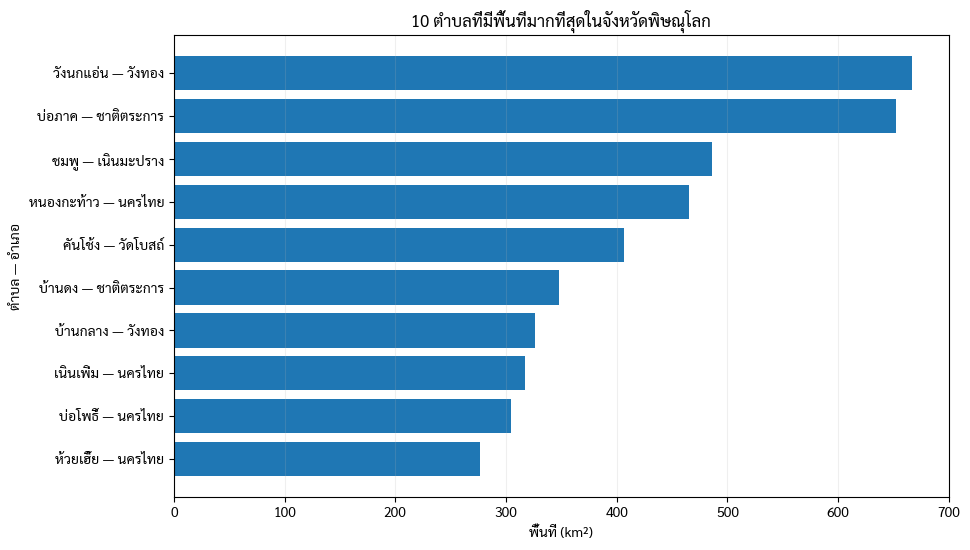

In [35]:
phs_top10_plot = (
    phs_top10
    .sort_values(
        "area_km2",
        ascending=True
    )
)

labels_phs_top10 = (
    phs_top10_plot[t_adm3_th].astype(str)
    + " — "
    + phs_top10_plot[t_adm2_th].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    labels_phs_top10,
    phs_top10_plot["area_km2"]
)

ax.set_title(
    "10 ตำบลที่มีพื้นที่มากที่สุดในจังหวัดพิษณุโลก"
)
ax.set_xlabel("พื้นที่ (km²)")
ax.set_ylabel("ตำบล — อำเภอ")
ax.grid(axis="x", alpha=0.2)

plt.show()

# Part H — Local Cartography

## 36. Visual hierarchy: ADM1 > ADM2 > ADM3

ใช้ linewidth ต่างกัน:

```text
ADM1  → thickest
ADM2  → medium
ADM3  → thinnest
```

ทำให้ผู้อ่านเห็นลำดับชั้นโดยไม่ต้องใช้สีมากเกินไป

## 37. Reference map — Tambons of Phitsanulok

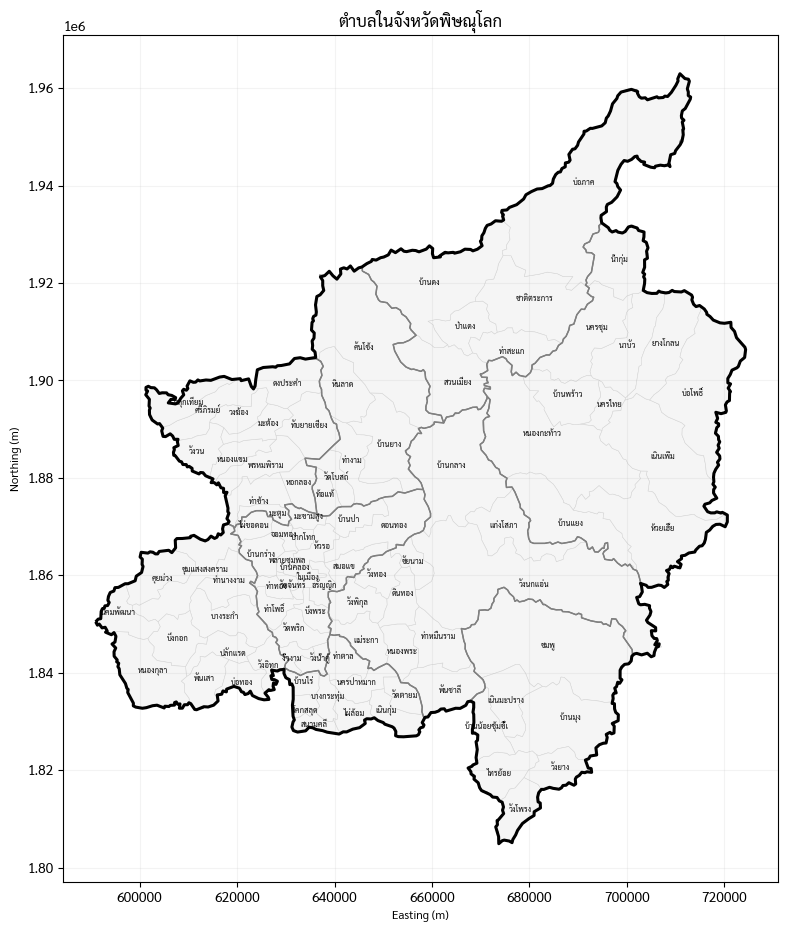

In [36]:
fig, ax = plt.subplots(figsize=(10, 11))

phs_tambon_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.35
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2
)

label_pts = (
    phs_tambon_utm.geometry
    .representative_point()
)

for idx, pt in label_pts.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            phs_tambon_utm.loc[
                idx,
                t_adm3_th
            ]
        ),
        fontsize=5.5,
        ha="center",
        va="center"
    )

ax.set_title(
    "ตำบลในจังหวัดพิษณุโลก"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.15)

plt.show()

ถ้า label บางส่วน overlap นั่นไม่ใช่ error ของ Python

แต่เป็นปัญหา **label density / cartographic generalization**

วิธีแก้มีหลายแบบ เช่น

- zoom เข้า
- label เฉพาะ subset
- ลด font size
- เลือกเฉพาะ important features
- ใช้ interactive tooltip แทน static label

## 38. Choropleth — พื้นที่ตำบลพิษณุโลก

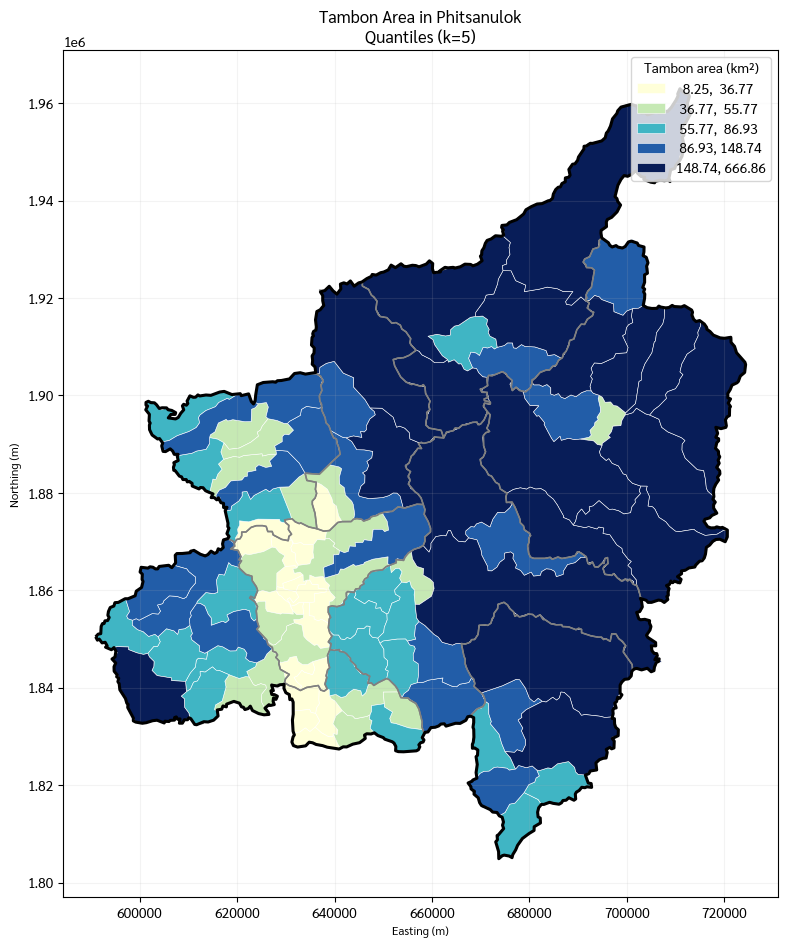

In [37]:
fig, ax = plt.subplots(figsize=(10, 11))

phs_tambon_utm.plot(
    ax=ax,
    column="area_km2",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={
        "title": "Tambon area (km²)"
    }
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.1
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2
)

ax.set_title(
    "Tambon Area in Phitsanulok\n"
    "Quantiles (k=5)"
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.15)

plt.show()

### Try it

เปลี่ยน

```python
scheme="Quantiles"
```

เป็น

```python
scheme="EqualInterval"
```

แล้วเปรียบเทียบว่า spatial pattern ที่มองเห็นเปลี่ยนหรือไม่

# Part I — Short Spatial QA/QC: ADM3 → ADM2

Notebook 04 สอน `gpd.sjoin()` ไปแล้ว  
ในบทนี้เราจะใช้เป็น **QA/QC แบบย่อ** เฉพาะจังหวัดพิษณุโลก

## 39. Representative point ของแต่ละตำบล

In [38]:
phs_tambon_points = phs_tambon[
    [
        t_adm3_code,
        t_adm3_th,
        t_adm2_code,
        t_adm2_th,
        "geometry"
    ]
].copy()

phs_tambon_points["geometry"] = (
    phs_tambon_points.geometry
    .representative_point()
)

phs_tambon_points = gpd.GeoDataFrame(
    phs_tambon_points,
    geometry="geometry",
    crs=phs_tambon.crs
)

phs_tambon_points.head()

,ADM3_PCODE,ADM3_TH,ADM2_PCODE,ADM2_TH,geometry
5407,TH650101,ในเมือง,TH6501,เมืองพิษณุโลก,POINT (100.26342 16.81433)
5408,TH650102,วังน้ำคู้,TH6501,เมืองพิษณุโลก,POINT (100.28513 16.6652)
5409,TH650103,วัดจันทร์,TH6501,เมืองพิษณุโลก,POINT (100.23485 16.80003)
5410,TH650104,วัดพริก,TH6501,เมืองพิษณุโลก,POINT (100.23511 16.72181)
5411,TH650105,ท่าทอง,TH6501,เมืองพิษณุโลก,POINT (100.20242 16.79787)


## 40. Spatial join กับ ADM2

In [39]:
phs_district_join = phs_district[
    [
        d_adm2_code,
        d_adm2_th,
        "geometry"
    ]
].copy()

phs_district_join = (
    phs_district_join.rename(
        columns={
            d_adm2_code: "SP_ADM2_PCODE",
            d_adm2_th: "SP_ADM2_TH"
        }
    )
)

phs_spatial_check = gpd.sjoin(
    phs_tambon_points,
    phs_district_join,
    how="left",
    predicate="within"
)

phs_spatial_check["match"] = (
    phs_spatial_check[t_adm2_code]
    .astype(str)
    ==
    phs_spatial_check["SP_ADM2_PCODE"]
    .astype(str)
)

display(
    phs_spatial_check[
        [
            t_adm3_th,
            t_adm2_th,
            "SP_ADM2_TH",
            "match"
        ]
    ].head(20)
)

,ADM3_TH,ADM2_TH,SP_ADM2_TH,match
5407,ในเมือง,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5408,วังน้ำคู้,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5409,วัดจันทร์,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5410,วัดพริก,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5411,ท่าทอง,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5412,ท่าโพธิ์,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5413,สมอแข,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5414,ดอนทอง,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5415,บ้านป่า,เมืองพิษณุโลก,เมืองพิษณุโลก,True
5416,ปากโทก,เมืองพิษณุโลก,เมืองพิษณุโลก,True


## 41. Agreement

In [40]:
match_count = (
    phs_spatial_check[
        "match"
    ].sum()
)

assigned_count = (
    phs_spatial_check[
        "SP_ADM2_PCODE"
    ].notna().sum()
)

agreement_pct = (
    100 * match_count / assigned_count
    if assigned_count > 0
    else np.nan
)

print(
    f"ADM3 → ADM2 spatial agreement: "
    f"{agreement_pct:.2f}%"
)

mismatch = phs_spatial_check[
    ~phs_spatial_check["match"]
    | phs_spatial_check[
        "SP_ADM2_PCODE"
    ].isna()
]

print("Mismatch / unassigned:", len(mismatch))

ADM3 → ADM2 spatial agreement: 100.00%
Mismatch / unassigned: 0


# Part J — Folium with Safe Web Layers & Basemap Switcher

ส่วนนี้แก้ architecture ของ Folium ใหม่ทั้งหมด เพื่อป้องกัน

```text
TypeError: Object of type Timestamp is not JSON serializable
```

หลักคือ **ห้ามส่ง GeoDataFrame เต็มจาก Shapefile เข้า Folium โดยตรง**

$$
\boxed{
Full\ GIS\ Layer
\rightarrow
Compact\ Web\ Layer
\rightarrow
Validated\ GeoJSON
\rightarrow
Folium
}
$$

ทุก derived layer เช่น Top 10 จะสร้างจาก compact web layer เท่านั้น

## 42. Helper — สร้าง Compact Web Layer

Web layer จะเก็บเฉพาะ attributes ที่ต้องใช้จริง

```text
code
name
area
geometry
```

และ normalize data type ก่อนส่งเข้า browser

In [41]:
def _json_safe_scalar(value):
    """Convert one scalar attribute to a JSON-safe Python value."""
    if value is None:
        return None

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(value, (str, int, float, bool)):
        return value

    return str(value)


def prepare_web_layer(
    gdf,
    fields,
    code_fields=None,
    numeric_fields=None,
    target_crs="EPSG:4326"
):
    """
    Prepare a compact, JSON-safe GeoDataFrame for Folium.
    """
    fields = [
        field for field in fields
        if field is not None and field in gdf.columns
    ]
    fields = list(dict.fromkeys(fields))

    web = gdf[
        fields + ["geometry"]
    ].copy()

    web = web.to_crs(target_crs)

    code_fields = code_fields or []
    numeric_fields = numeric_fields or []

    for col in code_fields:
        if col in web.columns:
            web[col] = web[col].map(
                lambda v:
                    None if pd.isna(v) else str(v)
            )

    for col in numeric_fields:
        if col in web.columns:
            web[col] = pd.to_numeric(
                web[col],
                errors="coerce"
            ).astype(float)

    for col in fields:
        if col not in code_fields and col not in numeric_fields:
            web[col] = web[col].map(
                _json_safe_scalar
            )

    return gpd.GeoDataFrame(
        web,
        geometry="geometry",
        crs=target_crs
    )


def to_safe_geojson(gdf):
    """
    Convert compact GeoDataFrame to a plain GeoJSON dictionary
    and validate with Python's standard JSON encoder.
    """
    geojson_dict = json.loads(
        gdf.to_json()
    )

    json.dumps(
        geojson_dict,
        ensure_ascii=False
    )

    return geojson_dict

## 43. สร้าง Canonical Web Layers

`phs_top10_web` จะถูกสร้างจาก `phs_tambon_web` ที่ clean แล้วเท่านั้น

In [42]:
phs_province_web = prepare_web_layer(
    phs_province_utm,
    fields=[
        p_adm1_code,
        p_adm1_th
    ],
    code_fields=[
        p_adm1_code
    ]
)

phs_district_web = prepare_web_layer(
    phs_district_utm,
    fields=[
        d_adm1_code,
        d_adm2_code,
        d_adm2_th
    ],
    code_fields=[
        d_adm1_code,
        d_adm2_code
    ]
)

phs_tambon_web = prepare_web_layer(
    phs_tambon_utm,
    fields=[
        t_adm1_code,
        t_adm1_th,
        t_adm2_code,
        t_adm2_th,
        t_adm3_code,
        t_adm3_th,
        "area_km2"
    ],
    code_fields=[
        t_adm1_code,
        t_adm2_code,
        t_adm3_code
    ],
    numeric_fields=[
        "area_km2"
    ]
)

phs_top10_codes = set(
    phs_top10[
        t_adm3_code
    ]
    .astype(str)
    .tolist()
)

phs_top10_web = (
    phs_tambon_web[
        phs_tambon_web[
            t_adm3_code
        ].isin(phs_top10_codes)
    ]
    .copy()
)

print("Province fields:", phs_province_web.columns.tolist())
print("District fields:", phs_district_web.columns.tolist())
print("Tambon fields  :", phs_tambon_web.columns.tolist())
print("Top 10 features:", len(phs_top10_web))

Province fields: ['ADM1_PCODE', 'ADM1_TH', 'geometry']
District fields: ['ADM1_PCODE', 'ADM2_PCODE', 'ADM2_TH', 'geometry']
Tambon fields  : ['ADM1_PCODE', 'ADM1_TH', 'ADM2_PCODE', 'ADM2_TH', 'ADM3_PCODE', 'ADM3_TH', 'area_km2', 'geometry']
Top 10 features: 10


## 44. Web GIS QA/QC — ตรวจ dtype ก่อนสร้าง map

In [43]:
print("Tambon web dtypes:")
display(phs_tambon_web.dtypes)

datetime_cols = (
    phs_tambon_web
    .select_dtypes(
        include=["datetime", "datetimetz"]
    )
    .columns
    .tolist()
)

print(
    "Datetime columns remaining:",
    datetime_cols
)

Tambon web dtypes:


,0
ADM1_PCODE,object
ADM1_TH,object
ADM2_PCODE,object
ADM2_TH,object
ADM3_PCODE,object
ADM3_TH,object
area_km2,float64
geometry,geometry


Datetime columns remaining: []


## 45. Validate GeoJSON Serialization

ถ้า cell นี้ผ่านครบทั้ง 4 layers แปลว่า `Timestamp` ไม่ได้ติดเข้า Folium แล้ว

In [44]:
province_geojson = to_safe_geojson(
    phs_province_web
)

district_geojson = to_safe_geojson(
    phs_district_web
)

tambon_geojson = to_safe_geojson(
    phs_tambon_web
)

top10_geojson = to_safe_geojson(
    phs_top10_web
)

for layer_name, layer_obj, layer_gdf in [
    ("Province", province_geojson, phs_province_web),
    ("District", district_geojson, phs_district_web),
    ("Tambon", tambon_geojson, phs_tambon_web),
    ("Top 10", top10_geojson, phs_top10_web),
]:
    json.dumps(
        layer_obj,
        ensure_ascii=False
    )

    print(
        f"{layer_name}: GeoJSON serialization OK "
        f"({len(layer_gdf)} features)"
    )

Province: GeoJSON serialization OK (1 features)
District: GeoJSON serialization OK (9 features)
Tambon: GeoJSON serialization OK (93 features)
Top 10: GeoJSON serialization OK (10 features)


## 46. Map center

In [45]:
center_pt = (
    phs_province_web.geometry
    .representative_point()
    .iloc[0]
)

print(
    "Map center:",
    round(center_pt.y, 5),
    round(center_pt.x, 5)
)

Map center: 17.03183 100.53815


## 47. Basemap helper

Basemap เป็น contextual layer และเลือกแสดงทีละหนึ่ง

In [46]:
def add_basemap(
    m,
    provider,
    name,
    show=False
):
    folium.TileLayer(
        tiles=provider.build_url(),
        attr=provider.html_attribution,
        name=name,
        overlay=False,
        control=True,
        show=show
    ).add_to(m)

## 48. Create Map + Basemap Switcher

In [47]:
m = folium.Map(
    location=[
        center_pt.y,
        center_pt.x
    ],
    zoom_start=8,
    tiles=None,
    control_scale=True
)

add_basemap(
    m,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m,
    xyz.Esri.WorldImagery,
    "Esri World Imagery (Satellite)",
    show=False
)

## 49. Province Boundary

In [48]:
province_group = folium.FeatureGroup(
    name="Province boundary",
    show=True
)

folium.GeoJson(
    province_geojson,
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#000000",
        "weight": 3
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[p_adm1_th],
        aliases=["จังหวัด:"]
    )
).add_to(province_group)

province_group.add_to(m)

## 50. District Boundaries

In [49]:
district_group = folium.FeatureGroup(
    name="District boundaries",
    show=True
)

folium.GeoJson(
    district_geojson,
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#555555",
        "weight": 1.5
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[d_adm2_th],
        aliases=["อำเภอ:"]
    )
).add_to(district_group)

district_group.add_to(m)

## 51. Tambon Boundaries + Tooltip

In [50]:
tambon_group = folium.FeatureGroup(
    name="Tambon boundaries",
    show=True
)

folium.GeoJson(
    tambon_geojson,
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "fillOpacity": 0.03,
        "color": "#777777",
        "weight": 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            t_adm3_th,
            t_adm2_th,
            t_adm1_th,
            "area_km2",
            t_adm3_code
        ],
        aliases=[
            "ตำบล:",
            "อำเภอ:",
            "จังหวัด:",
            "Area (km²):",
            "Code:"
        ],
        localize=True
    )
).add_to(tambon_group)

tambon_group.add_to(m)

## 52. Tambon Area Choropleth

In [51]:
tambon_choropleth_data = (
    phs_tambon_web[
        [
            t_adm3_code,
            "area_km2"
        ]
    ]
    .copy()
)

tambon_choropleth_data[
    t_adm3_code
] = (
    tambon_choropleth_data[
        t_adm3_code
    ]
    .astype(str)
)

tambon_choropleth_data[
    "area_km2"
] = pd.to_numeric(
    tambon_choropleth_data[
        "area_km2"
    ],
    errors="coerce"
)

folium.Choropleth(
    geo_data=tambon_geojson,
    data=tambon_choropleth_data,
    columns=[
        t_adm3_code,
        "area_km2"
    ],
    key_on=(
        "feature.properties."
        + t_adm3_code
    ),
    fill_color="YlGnBu",
    fill_opacity=0.60,
    line_opacity=0.4,
    legend_name="Tambon area (km²)",
    name="Tambon area choropleth",
    show=False
).add_to(m)

## 53. Tambon Labels

In [52]:
label_group = folium.FeatureGroup(
    name="Tambon labels",
    show=False
)

label_points_web = (
    phs_tambon_web.geometry
    .representative_point()
)

for idx, pt in label_points_web.items():
    tambon_name = str(
        phs_tambon_web.loc[
            idx,
            t_adm3_th
        ]
    )

    folium.Marker(
        location=[
            pt.y,
            pt.x
        ],
        icon=folium.DivIcon(
            html=(
                "<div style='"
                "font-size:10px;"
                "font-weight:bold;"
                "color:#111;"
                "text-shadow:"
                "1px 1px 2px white,"
                "-1px -1px 2px white;"
                "white-space:nowrap;'>"
                f"{tambon_name}"
                "</div>"
            )
        )
    ).add_to(label_group)

label_group.add_to(m)

## 54. Highlight Top 10 Largest Tambons

Top 10 ใช้ `top10_geojson` ที่ผ่าน serialization test แล้ว

In [53]:
top10_group = folium.FeatureGroup(
    name="Top 10 largest tambons",
    show=True
)

folium.GeoJson(
    top10_geojson,
    style_function=lambda feature: {
        "fillColor": "#ff9800",
        "fillOpacity": 0.28,
        "color": "#ff4d00",
        "weight": 2
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            t_adm3_th,
            t_adm2_th,
            "area_km2"
        ],
        aliases=[
            "ตำบล:",
            "อำเภอ:",
            "Area (km²):"
        ],
        localize=True
    )
).add_to(top10_group)

top10_group.add_to(m)

## 55. Layer Control

Basemap เป็น radio button  
Operational layers เป็น checkbox

In [54]:
folium.LayerControl(
    collapsed=False
).add_to(m)

m

### Visual Interpretation

ลองเปลี่ยนเป็น **Esri World Imagery** แล้วเปิด/ปิด

- Province boundary
- District boundaries
- Tambon boundaries
- Tambon area choropleth
- Tambon labels
- Top 10 largest tambons

> **Visual interpretation ≠ quantitative land-cover classification**

### Troubleshooting Rule

ถ้า Notebook ต่อไปพบ

```text
TypeError: Object of type Timestamp is not JSON serializable
```

อย่าเปลี่ยนทุก column เป็น string เพราะตัวแปรเชิงปริมาณจะเสีย type

ให้ใช้ pattern:

```text
Full GIS layer
↓
select required attributes
↓
normalize types
↓
validate GeoJSON
↓
Folium
```

# Part K — Publication-quality Maps

## 53. North arrow + projected scale bar

In [55]:
def add_north_arrow(
    ax,
    x=0.92,
    y=0.10,
    size=0.09
):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.4,
            color="black"
        )
    )


def choose_scale_m(width_m):
    candidates = np.array([
        5_000,
        10_000,
        20_000,
        50_000,
        100_000,
        200_000,
        500_000,
        1_000_000
    ])

    target = width_m / 4

    return int(
        candidates[
            np.argmin(
                np.abs(
                    candidates - target
                )
            )
        ]
    )


def add_projected_scalebar(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width_m = xmax - xmin
    height_m = ymax - ymin

    scale_m = choose_scale_m(width_m)

    x0 = xmin + 0.08 * width_m
    y0 = ymin + 0.06 * height_m
    x1 = x0 + scale_m

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=3
    )

    tick = 0.01 * height_m

    ax.plot(
        [x0, x0],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.plot(
        [x1, x1],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.02 * height_m,
        f"{scale_m/1000:g} km",
        ha="center",
        va="bottom",
        fontsize=8.5
    )

## 54. Publication Map 1 — Thailand Tambon Area

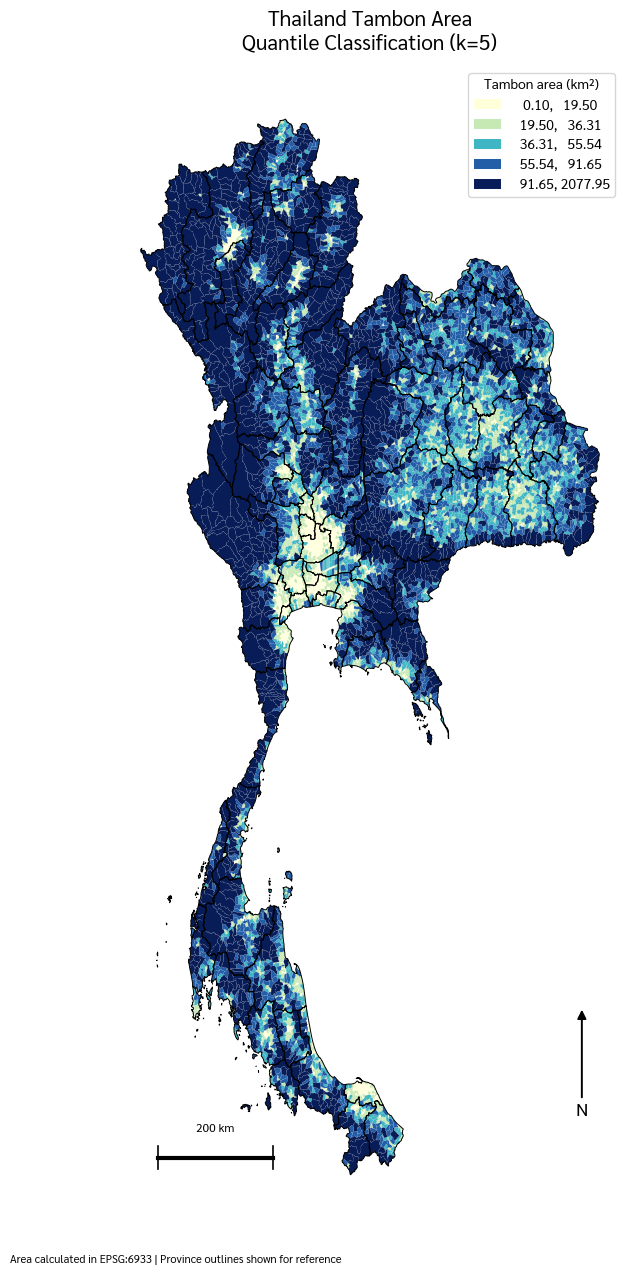

In [56]:
province_ea = province.to_crs(
    "EPSG:6933"
)

fig_national, ax = plt.subplots(
    figsize=(9, 13)
)

tambon_ea.plot(
    ax=ax,
    column="area_km2",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.03,
    legend_kwds={
        "title": "Tambon area (km²)"
    }
)

province_ea.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.7
)

ax.set_title(
    "Thailand Tambon Area\n"
    "Quantile Classification (k=5)",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_national.text(
    0.10,
    0.025,
    "Area calculated in EPSG:6933 | "
    "Province outlines shown for reference",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 55. Publication Map 2 — Top 50 Largest Tambons

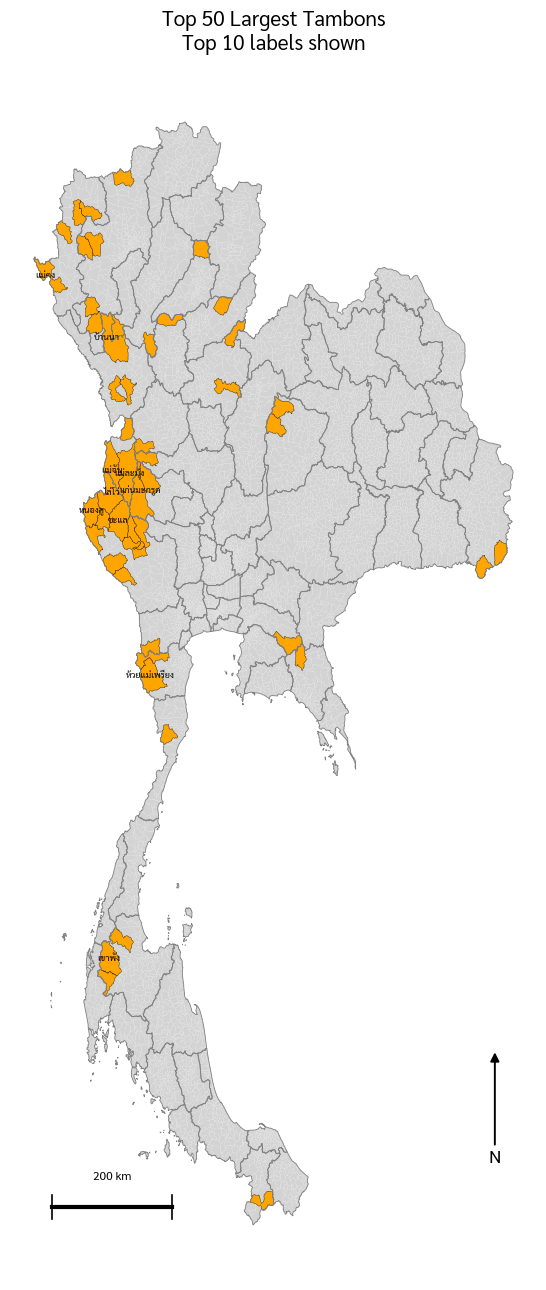

In [57]:
fig_top50, ax = plt.subplots(
    figsize=(9, 13)
)

tambon_ea.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.03
)

province_ea.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.6
)

top50_map.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=0.25
)

for idx, pt in top10_pts.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            top10_map.loc[
                idx,
                t_adm3_th
            ]
        ),
        fontsize=6.5,
        ha="center",
        va="center"
    )

ax.set_title(
    "Top 50 Largest Tambons\n"
    "Top 10 labels shown",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

plt.tight_layout()

plt.show()

## 56. Publication Map 3 — Phitsanulok Tambon Reference Map

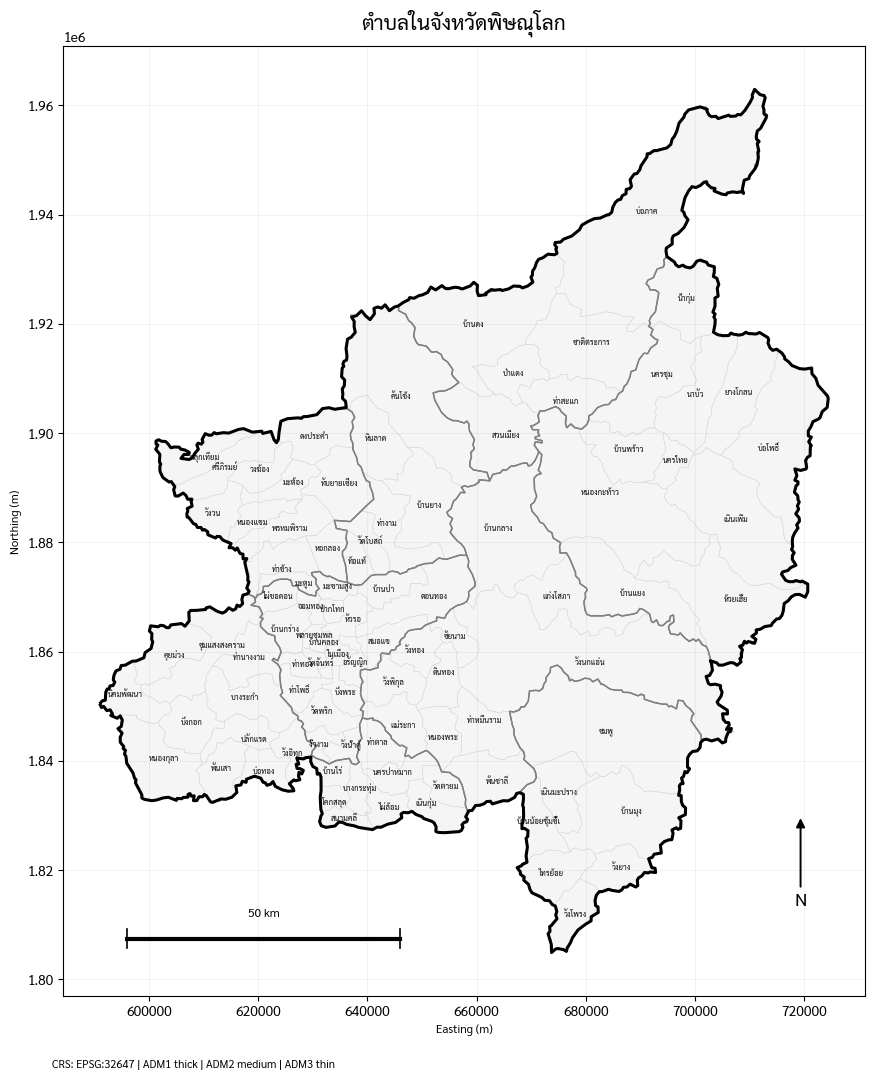

In [58]:
fig_phs_ref, ax = plt.subplots(
    figsize=(10, 11)
)

phs_tambon_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.35
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2
)

for idx, pt in label_pts.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            phs_tambon_utm.loc[
                idx,
                t_adm3_th
            ]
        ),
        fontsize=5.5,
        ha="center",
        va="center"
    )

ax.set_title(
    "ตำบลในจังหวัดพิษณุโลก",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.15)

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_phs_ref.text(
    0.10,
    0.025,
    "CRS: EPSG:32647 | "
    "ADM1 thick | ADM2 medium | ADM3 thin",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 57. Publication Map 4 — Phitsanulok Tambon Area

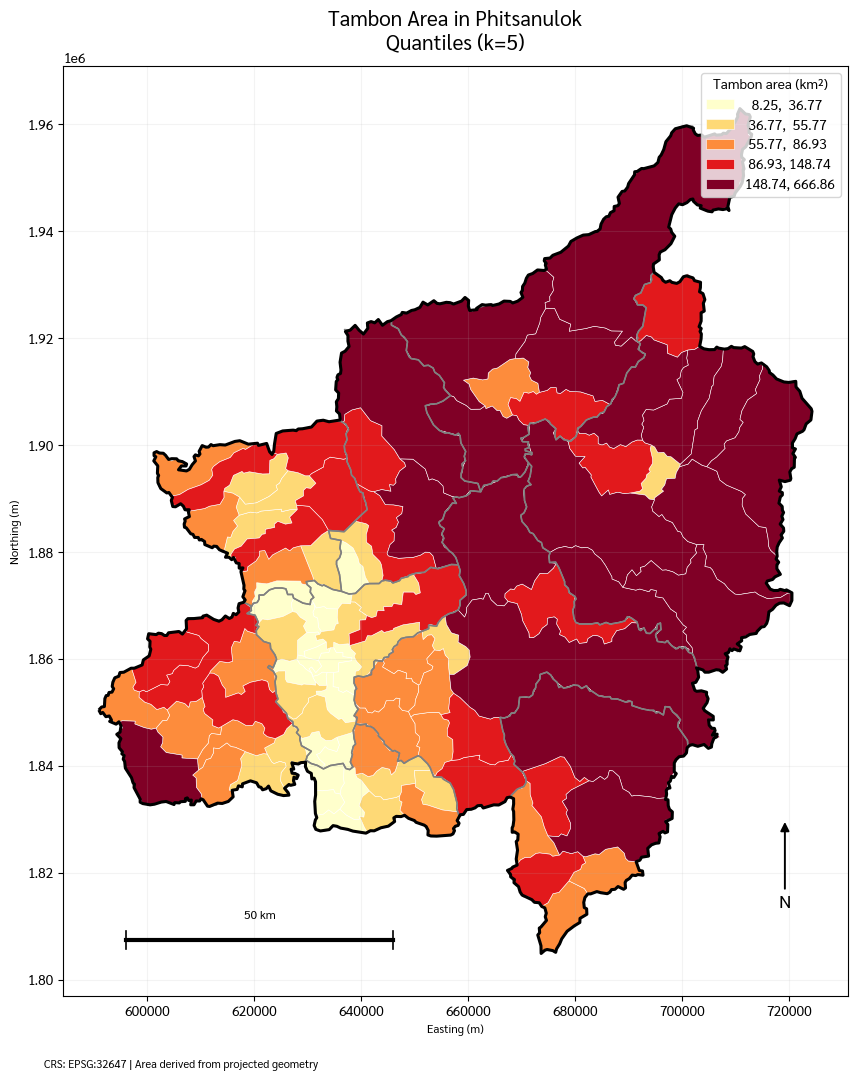

In [59]:
fig_phs_area, ax = plt.subplots(
    figsize=(10, 11)
)

phs_tambon_utm.plot(
    ax=ax,
    column="area_km2",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={
        "title": "Tambon area (km²)"
    }
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.1
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.2
)

ax.set_title(
    "Tambon Area in Phitsanulok\n"
    "Quantiles (k=5)",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.15)

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_phs_area.text(
    0.10,
    0.025,
    "CRS: EPSG:32647 | "
    "Area derived from projected geometry",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

# Part L — Export

## 58. Output folders

In [60]:
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [
    MAP_DIR,
    VECTOR_DIR,
    TABLE_DIR,
    HTML_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

## 59. Export PNG 300 dpi

In [61]:
fig_national.savefig(
    MAP_DIR / "thailand_tambon_area_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_top50.savefig(
    MAP_DIR / "top50_largest_tambons_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_phs_ref.savefig(
    MAP_DIR / "phitsanulok_tambons_reference_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_phs_area.savefig(
    MAP_DIR / "phitsanulok_tambon_area_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

print("PNG maps exported.")

PNG maps exported.


## 60. Export GeoPackage

In [62]:
national_gpkg = (
    VECTOR_DIR
    / "thailand_tambon_analysis.gpkg"
)

if national_gpkg.exists():
    national_gpkg.unlink()

tambon_ea.to_file(
    national_gpkg,
    layer="tambon_area",
    driver="GPKG"
)

phs_gpkg = (
    VECTOR_DIR
    / "phitsanulok_tambons.gpkg"
)

if phs_gpkg.exists():
    phs_gpkg.unlink()

phs_tambon_utm.to_file(
    phs_gpkg,
    layer="phitsanulok_tambons",
    driver="GPKG"
)

print("Saved:", national_gpkg)
print("Saved:", phs_gpkg)

Saved: /content/gis05_outputs/vectors/thailand_tambon_analysis.gpkg
Saved: /content/gis05_outputs/vectors/phitsanulok_tambons.gpkg


## 61. Export Phitsanulok Tambons เป็น Shapefile ZIP

In [63]:
shp_folder = (
    VECTOR_DIR
    / "phitsanulok_tambons_shp"
)

if shp_folder.exists():
    shutil.rmtree(shp_folder)

shp_folder.mkdir(
    parents=True,
    exist_ok=True
)

shp_path = (
    shp_folder
    / "phitsanulok_tambons.shp"
)

phs_export_cols = [
    t_adm1_code,
    t_adm1_th,
    t_adm2_code,
    t_adm2_th,
    t_adm3_code,
    t_adm3_th,
    "area_km2",
    "geometry"
]

phs_export = (
    phs_tambon_utm[
        phs_export_cols
    ].copy()
)

phs_export.to_file(
    shp_path,
    driver="ESRI Shapefile",
    encoding="UTF-8"
)

phs_zip = shutil.make_archive(
    str(
        VECTOR_DIR
        / "phitsanulok_tambons"
    ),
    "zip",
    root_dir=shp_folder
)

print("Saved:", phs_zip)

Saved: /content/gis05_outputs/vectors/phitsanulok_tambons.zip


## 62. Export CSV tables

In [64]:
top50[
    [
        "rank",
        t_adm1_th,
        t_adm2_th,
        t_adm3_th,
        "area_km2"
    ]
].to_csv(
    TABLE_DIR / "top50_largest_tambons.csv",
    index=False,
    encoding="utf-8-sig"
)

tambon_count_province.to_csv(
    TABLE_DIR / "tambon_count_by_province.csv",
    index=False,
    encoding="utf-8-sig"
)

tambon_count_district.to_csv(
    TABLE_DIR / "tambon_count_by_district.csv",
    index=False,
    encoding="utf-8-sig"
)

phs_summary_table = (
    phs_tambon_utm[
        [
            t_adm2_th,
            t_adm3_th,
            t_adm3_code,
            "area_km2"
        ]
    ]
    .sort_values(
        "area_km2",
        ascending=False
    )
)

phs_summary_table.to_csv(
    TABLE_DIR / "phitsanulok_tambon_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV tables exported.")

CSV tables exported.


## 63. Export Folium HTML

In [65]:
html_path = (
    HTML_DIR
    / "phitsanulok_tambon_interactive.html"
)

m.save(html_path)

print("Saved:", html_path)

Saved: /content/gis05_outputs/html/phitsanulok_tambon_interactive.html


## 64. ตรวจ outputs

In [66]:
for p in sorted(
    OUTPUT_DIR.rglob("*")
):
    if p.is_file():
        print(
            p.relative_to(
                OUTPUT_DIR
            ),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

html/phitsanulok_tambon_interactive.html (614.1 KB)
maps/phitsanulok_tambon_area_300dpi.png (705.8 KB)
maps/phitsanulok_tambons_reference_300dpi.png (806.7 KB)
maps/thailand_tambon_area_300dpi.png (1,882.5 KB)
maps/top50_largest_tambons_300dpi.png (1,314.3 KB)
tables/phitsanulok_tambon_summary.csv (7.2 KB)
tables/tambon_count_by_district.csv (53.9 KB)
tables/tambon_count_by_province.csv (2.5 KB)
tables/top50_largest_tambons.csv (4.6 KB)
vectors/phitsanulok_tambons.gpkg (200.0 KB)
vectors/phitsanulok_tambons.zip (38.9 KB)
vectors/phitsanulok_tambons_shp/phitsanulok_tambons.cpg (0.0 KB)
vectors/phitsanulok_tambons_shp/phitsanulok_tambons.dbf (46.1 KB)
vectors/phitsanulok_tambons_shp/phitsanulok_tambons.prj (0.4 KB)
vectors/phitsanulok_tambons_shp/phitsanulok_tambons.shp (61.1 KB)
vectors/phitsanulok_tambons_shp/phitsanulok_tambons.shx (0.8 KB)
vectors/thailand_tambon_analysis.gpkg (6,704.0 KB)


# Concept Check

ลองตอบโดยไม่ย้อนดู code

1. ADM3 อยู่ตรงไหนใน administrative hierarchy?
2. `ADM3_PCODE` ต่างจาก `ADM2_PCODE` อย่างไร?
3. simplified geometry มีข้อดีและข้อจำกัดอย่างไร?
4. ทำไม national tambon map ไม่ควรใส่ label ทุกตำบล?
5. ทำไมใช้ EPSG:6933 สำหรับ national area comparison?
6. ทำไมใช้ EPSG:32647 สำหรับ Phitsanulok local analysis?
7. จำนวนตำบลมาก แปลว่าพื้นที่อำเภอใหญ่หรือไม่?
8. ทำไม Top 50 table อาจแสดงครบ แต่ map label เฉพาะ Top 10?
9. representative point ช่วย QA/QC hierarchy อย่างไร?
10. Basemap imagery ต่างจาก analytical layer อย่างไร?

# Exercise 1 — Top 50 Largest Tambons

ทำ workflow:

```text
calculate area
↓
Top 50 table
↓
Top 20 graph
↓
Top 50 map
↓
Top 10 labels
```

ตอบ:

> ทำไมไม่ควร label ทั้ง 50 บน national map?

# Exercise 2 — เลือกจังหวัดอื่น

เลือกหนึ่งจังหวัด เช่น

```text
เชียงใหม่
นครราชสีมา
สุราษฎร์ธานี
```

แล้วทำ

```text
Query ADM3
↓
Count tambons
↓
Area
↓
Top 10
↓
Choropleth
↓
Labels
↓
Folium
```

# Exercise 3 — Tambon Count vs District Area

เลือกจังหวัดหนึ่ง แล้วสร้างตาราง:

```text
District
Tambon count
District area
```

ตอบ:

> อำเภอที่มีพื้นที่มากที่สุด มีจำนวนตำบลมากที่สุดด้วยหรือไม่?

นี่เป็นการทดสอบแนวคิด

$$
Count
eq Area
$$

# Exercise 4 — Visual Interpretation with Esri World Imagery

ใน Folium:

1. เปลี่ยน basemap เป็น **Esri World Imagery**
2. เปิด Tambon boundaries
3. เปิด District boundaries
4. เปิด Tambon labels
5. เลือกตำบล 3 แห่งที่ landscape ต่างกัน

อธิบายเชิงคุณภาพ:

- urban
- agricultural
- mountainous / forested
- river-related landscape

> ห้ามเรียกผลนี้ว่า land-cover classification เพราะยังไม่มี quantitative classification

# Exercise 5 — QGIS

เปิด

```text
phitsanulok_tambons.gpkg
```

ใน QGIS แล้วทดลอง:

- label ด้วยชื่อ `ADM3_TH`
- graduated symbology ด้วย `area_km2`
- overlay district boundary
- เปรียบเทียบกับ Python output

สังเกตว่าการจัด label ใน desktop GIS และ Python มี workflow ต่างกันอย่างไร

# MSc Challenge — Cartographic Generalization

ใช้ ADM3 layer เดียวกัน แต่สร้างแผนที่ 3 extent:

```text
Thailand
Phitsanulok Province
Mueang Phitsanulok District
```

เปรียบเทียบว่าแต่ละ extent ควรใช้

- linewidth
- label density
- font size
- class count
- legend detail
- annotations

ต่างกันอย่างไร

คำถาม:

> ทำไม symbology เดียวกันจึงไม่เหมาะกับทุก map scale?

หลัก:

$$
\boxed{
National\ overview
\neq
local\ detailed\ map
}
$$

# Summary

Notebook 05 เพิ่มทักษะการจัดการข้อมูล polygon ที่ละเอียดและมีจำนวนมาก

$$
\boxed{
Detailed\ polygons
+
hierarchy
+
measurement
+
filtering
+
cartographic\ selection
}
$$

สิ่งที่ต้องจำ:

> **More features ≠ more useful labels**

> **Map detail must match map scale**

> **Filter before you visualize**

> **National overview and local analysis require different cartographic strategies**

> **Visual interpretation ≠ quantitative classification**

## ต่อไป: Notebook 06

**Village Point GIS — Point Data, Point-in-Polygon, Spatial Join & Density**

Notebook 06 จะเปลี่ยน geometry type จาก

```text
Polygon
→ Point
```

แล้วตอบคำถามว่า

> หมู่บ้านแต่ละจุดอยู่ในอำเภอ/ตำบลใด และเราจะนับจำนวนหมู่บ้านต่อ polygon หรือคำนวณ density ได้อย่างไร?